In [1]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.calc
import aeolus.coord

import warnings
warnings.filterwarnings("ignore")

In [2]:

## Loading the files for the six different surface pressures

point_25 = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_0p25bar-m09.nc?download=1')
point_5 = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_0p5bar-m09.nc?download=1')
one = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_1bar-m09.nc?download=1')
two = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_2bar-m09.nc?download=1')
four = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_4bar-m09.nc?download=1')
ten = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_10bar-m09.nc?download=1')


# Surface pressures, unit: bar
point_25_surface_pressure_bar, point_5_surface_pressure_bar, one_surface_pressure_bar, two_surface_pressure_bar, four_surface_pressure_bar, ten_surface_pressure_bar = 0.25, 0.5, 1, 2, 4, 10

In [3]:
# one

In [4]:
## Extract air pressure and temperature cubes and reduce to their temporal means (from 4D to 3D)
## Average over the dayside (from 3D to 2D)
## Retrieve and flatten the data points for air temperature and air pressure

def dayside_tempfunction(cube):
    air_temperature = cube.extract_cube('m01s16i004')
    air_temp_roll = aeolus.coord.roll_cube_pm180(air_temperature, add_shift=0)
    dayside_airtemp = air_temp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
    dayside_airtemp_mean = dayside_airtemp.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)
    # DAYSIDE_AIRTEMP_FLATTEN = (dayside_airtemp_mean.data).flatten()
    # return DAYSIDE_AIRTEMP_FLATTEN
    return dayside_airtemp_mean

def dayside_LFRfunction(cube):
    LFR = cube.extract_cube('m01s21i104')
    LFR_roll = aeolus.coord.roll_cube_pm180(LFR, add_shift=0)
    dayside_LFR = LFR_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
    dayside_LFR_mean = dayside_LFR.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)
    # DAYSIDE_LFR_FLATTEN = (dayside_LFR_mean.data).flatten()
    # return DAYSIDE_LFR_FLATTEN
    return dayside_LFR_mean

In [5]:
## Air temperature
point_25_day_temps = dayside_tempfunction(point_25)
point_5_day_temps = dayside_tempfunction(point_5)
one_day_temps = dayside_tempfunction(one)
two_day_temps = dayside_tempfunction(two)
four_day_temps = dayside_tempfunction(four)
ten_day_temps = dayside_tempfunction(ten)

## LFR
point_25_day_LFR = dayside_LFRfunction(point_25)
point_5_day_LFR = dayside_LFRfunction(point_5)
one_day_LFR = dayside_LFRfunction(one)
two_day_LFR = dayside_LFRfunction(two)
four_day_LFR = dayside_LFRfunction(four)
ten_day_LFR = dayside_LFRfunction(ten)

In [ ]:
## Extract air pressure and temperature cubes and reduce to their temporal means (from 4D to 3D)
## Average vertically over altitude levels (from 3D to 2D)
## Retrieve and flatten the data points for air temperature and air pressure

def full_air_temperature(cube):
    air_temp = cube.extract_cube('m01s16i004')
    air_temp_mean = aeolus.calc.stats.vertical_mean(air_temp)
    return air_temp_mean

def full_LFR(cube):
    LFR = cube.extract_cube('m01s21i104')
    return LFR

In [ ]:
## Global air temperature
point_25_full_temps = full_air_temperature(point_25)
point_5_full_temps = full_air_temperature(point_5)
one_full_temps = full_air_temperature(one)
two_full_temps = full_air_temperature(two)
four_full_temps = full_air_temperature(four)
ten_full_temps = full_air_temperature(ten)

## Global LFR
point_25_full_LFR = full_LFR(point_25)
point_5_full_LFR = full_LFR(point_5)
one_full_LFR = full_LFR(one)
two_full_LFR = full_LFR(two)
four_full_LFR = full_LFR(four)
ten_full_LFR = full_LFR(ten)


In [ ]:
## Extracting altitude levels

point_25_altitudes = point_25_day_temps.coord('level_height').points /1000
point_5_altitudes = point_5_day_temps.coord('level_height').points /1000
one_altitudes = one_day_temps.coord('level_height').points /1000
two_altitudes = two_day_temps.coord('level_height').points /1000
four_altitudes = four_day_temps.coord('level_height').points /1000
ten_altitudes = ten_day_temps.coord('level_height').points /1000

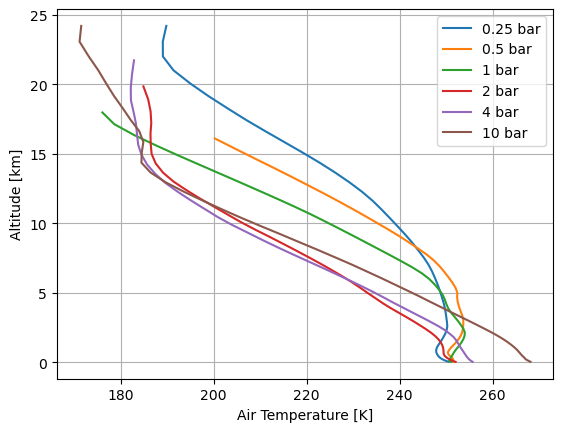

In [ ]:
## Plotting dayside-averaged temperature-altitude profiles for the different surface pressures

plt.plot(point_25_day_temps.data, point_25_altitudes, label='0.25 bar')
plt.plot(point_5_day_temps.data, point_5_altitudes, label='0.5 bar') 
plt.plot(one_day_temps.data, one_altitudes, label='1 bar')
plt.plot(two_day_temps.data, two_altitudes, label='2 bar') 
plt.plot(four_day_temps.data, four_altitudes, label='4 bar') 
plt.plot(ten_day_temps.data, ten_altitudes, label='10 bar') 


plt.xlabel('Air Temperature [K]')
plt.ylabel('Altitude [km]')
# plt.title('Air Temperature Profiles')
# plt.ylim(0, 16)
plt.legend()
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/all_m09_pressures_temp_profiles.pdf')
plt.show()


In [ ]:
## Extract data from global LFR
point_25_full_LFRdata = point_25_full_LFR.data
point_5_full_LFRdata = point_5_full_LFR.data
one_full_LFRdata = one_full_LFR.data
two_full_LFRdata = two_full_LFR.data
four_full_LFRdata = four_full_LFR.data
ten_full_LFRdata = ten_full_LFR.data

In [ ]:
## Extract data from global air temperature
point_25_full_tempsdata = point_25_full_temps.data
point_5_full_tempsdata = point_5_full_temps.data
one_full_tempsdata = one_full_temps.data
two_full_tempsdata = two_full_temps.data
four_full_tempsdata = four_full_temps.data
ten_full_tempsdata = ten_full_temps.data

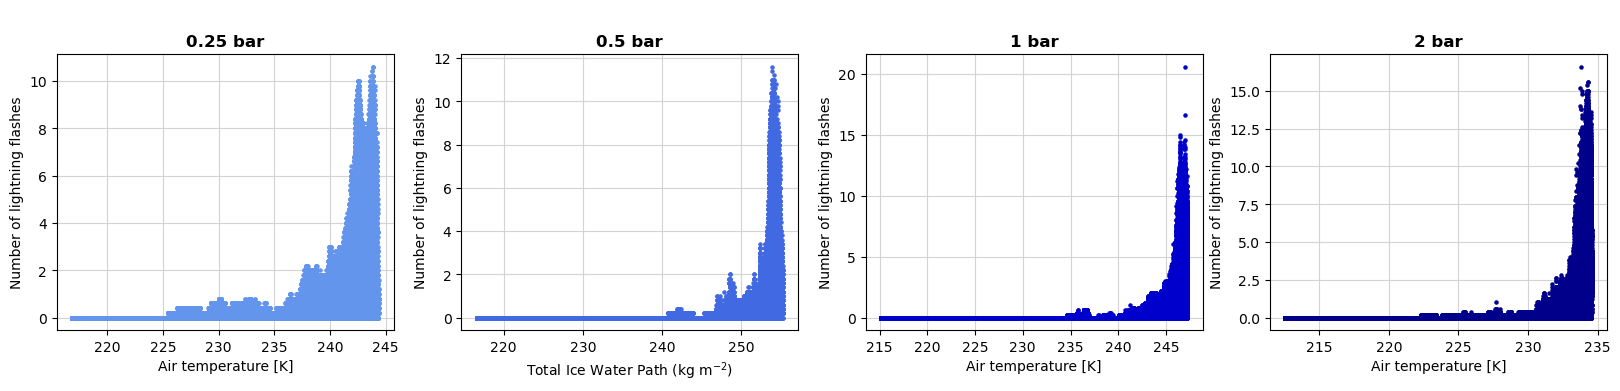

In [ ]:
## LFR-mean air temperature (dayside zonal mean)

LFR_airtemp_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
LFR_airtemp_fig.suptitle('', fontsize='x-large', weight='bold')

ax1.scatter(point_25_full_tempsdata, point_25_full_LFRdata, s = 5, facecolor = 'cornflowerblue', zorder = 3)
ax1.grid(True, color = 'lightgrey', zorder = 0)
ax1.set_xlabel("Mean air temperature [K]")
ax1.set_ylabel("Number of lightning flashes")
ax1.set_title('0.25 bar', weight='bold')

ax2.scatter(point_5_full_tempsdata, point_5_full_LFRdata, s = 5, facecolor = 'royalblue', zorder = 3)
ax2.grid(True, color = 'lightgrey', zorder = 0)
ax2.set_xlabel("Mean air temperature [K]")
ax2.set_ylabel("Number of lightning flashes")
ax2.set_title('0.5 bar', weight='bold')

ax3.scatter(one_full_tempsdata, one_full_LFRdata, s = 5, facecolor = 'mediumblue', zorder = 3)
ax3.grid(True, color = 'lightgrey', zorder = 0)
ax3.set_xlabel("Mean air temperature [K]")
ax3.set_ylabel("Number of lightning flashes")
ax3.set_title('1 bar', weight='bold')

ax4.scatter(two_full_tempsdata, two_full_LFRdata, s = 5, facecolor = 'darkblue', zorder = 3)
ax4.grid(True, color = 'lightgrey', zorder = 0)
ax4.set_xlabel("Mean air temperature [K]")
ax4.set_ylabel("Number of lightning flashes")
ax4.set_title('2 bar', weight='bold')


LFR_airtemp_fig.legend(
    ncols=5,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    frameon=False
)

LFR_airtemp_fig.subplots_adjust(top=0.8)


LFR_airtemp_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/AirTemp_LFR.png',
    bbox_inches="tight",
    pad_inches=0
)

LFR_airtemp_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/AirTemp_LFR.pdf',
    bbox_inches="tight",
    pad_inches=0
)

In [11]:
one

[<iris 'Cube' of graupel_water_path / (kg m-2) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of graupel_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_area_fraction_assuming_maximum_random_overlap / (1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of Number_of_lightning_flashes / (1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 50; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of total_ice_water_path / (kg m-2) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of air_temperature / (K) (model_level_number: 50; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_ice_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_liquid_water_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of stratiform_rainfall_flux / (kg m-2 s-1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of stratiform_snowfall_flux / (kg m-2 s-1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of surface_temperature / (K) (latitude: 1920; longitude: 2560)>]

In [ ]:
## Cube loading functions

def total_ice_water_path(cubelist):
    TIWP = cubelist.extract_cube('m01s21i103')
    return TIWP.data

def graupel_water_path(cubelist):
    GWP = cubelist.extract_cube('m01s21i102')
    return GWP.data

def graupel_mixing_ratio(cubelist):
    GMR = cubelist.extract_cube('m01s00i395')
    GMRmean = aeolus.calc.stats.vertical_mean(GMR)
    return GMRmean.data

def lightning_flash_rate(cubelist):
    LFR = cubelist.extract_cube('m01s21i104')
    return LFR.data

def cloud_volume_fraction_in_atmosphere(cubelist):
    CVFA = cubelist.extract_cube('m01s00i266')
    CVFAmean = aeolus.calc.stats.vertical_mean(CVFA)
    return CVFAmean.data

def air_temperature(cubelist):
    airtemp = cubelist.extract_cube('m01s16i004')
    airtempmean = aeolus.calc.stats.vertical_mean(airtemp)
    return airtempmean.data

def cloud_ice_mixing_ratio(cubelist):
    CIMP = cubelist.extract_cube('m01s00i393')
    CIMPmean = aeolus.calc.stats.vertical_mean(CIMP)
    return CIMPmean.data

def cloud_water_mixing_ratio(cubelist):
    CWMP = cubelist.extract_cube('m01s00i392')
    CWMPmean = aeolus.calc.stats.vertical_mean(CWMP)
    return CWMPmean.data

def surface_temp(cubelist):
    surftemp = cubelist.extract_cube('m01s00i024')
    return surftemp.data


In [ ]:
## Extracting cloud characteristics for 1 bar surface pressure

t_i_w_p = total_ice_water_path(one)
g_w_p = graupel_water_path(one)
g_m_r = graupel_mixing_ratio(one)
l_f_r = lightning_flash_rate(one)
c_v_f_a = cloud_volume_fraction_in_atmosphere(one)
a_t = air_temperature(one)
c_i_m_r = cloud_ice_mixing_ratio(one)
c_w_m_r = cloud_water_mixing_ratio(one)
s_t = surface_temp(one)

In [1]:
# plt.scatter(s_t, l_f_r)

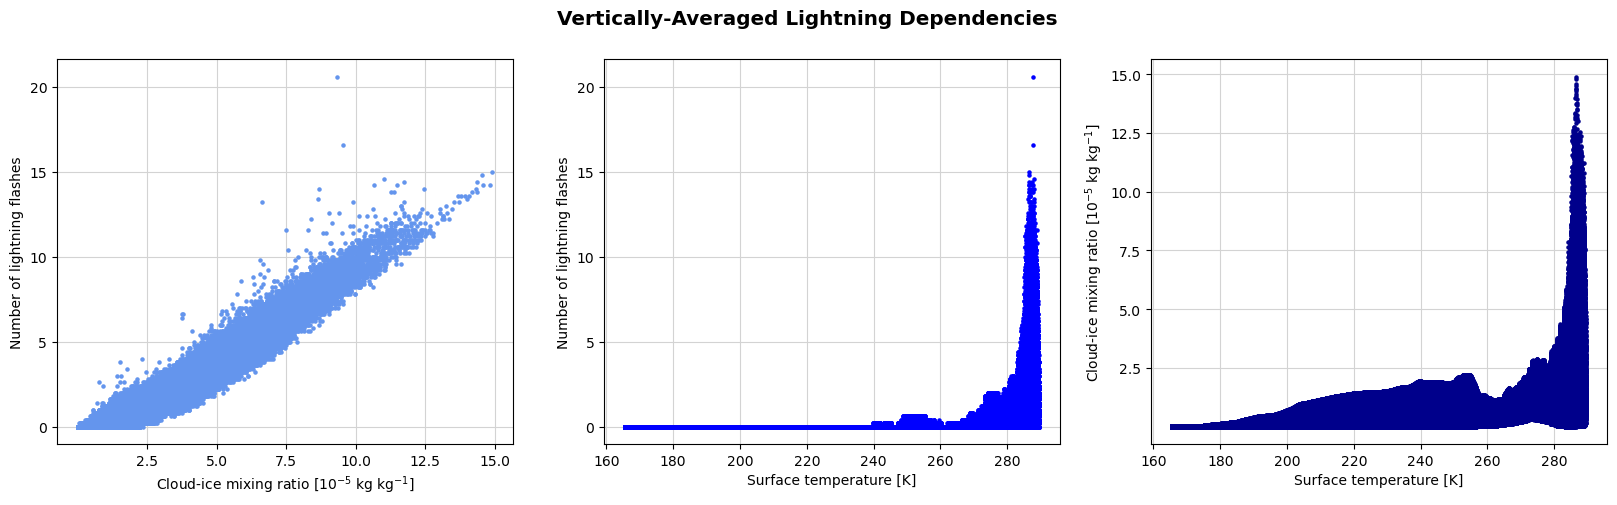

In [ ]:
## Plotting the dependency of LFR on surface temp and cloud-ice mixing ratio
## Also cloud-ice mixing ratio against surface temperature to see correlation
LFR_dependencies, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
LFR_dependencies.suptitle('Vertically-Averaged Lightning Dependencies', fontsize='x-large', weight='bold')

# ax1.scatter(t_i_w_p, l_f_r, s = 5, facecolor = 'cornflowerblue', zorder = 3)
# ax1.grid(True, color = 'lightgrey', zorder = 0)
# ax1.set_xlabel(r"Total ice water path [kg m$^{-2}$]")
# ax1.set_ylabel("Number of lightning flashes")
# ax1.set_title('Vertical Ice Extent')

# ax2.scatter(c_v_f_a, l_f_r, s = 5, facecolor = 'royalblue', zorder = 3)
# ax2.grid(True, color = 'lightgrey', zorder = 0)
# ax2.set_xlabel(r"Cloud volume fraction in atmosphere")
# ax2.set_ylabel("Number of lightning flashes")
# ax2.set_title('Cloud Volume Fraction')

ax1.scatter(c_i_m_r, l_f_r, s = 5, facecolor = 'cornflowerblue', zorder = 3)
ax1.grid(True, color = 'lightgrey', zorder = 0)
ax1.set_xticks(
    [2.5e-5, 5.0e-5, 7.5e-5, 1.0e-4, 1.25e-4, 1.5e-4], 
    ['2.5', '5.0', '7.5', '10.0', '12.5', '15.0']
    )
ax1.set_xlabel(r"Cloud-ice mixing ratio [$10^{-5}$ kg kg$^{-1}$]")
ax1.set_ylabel("Number of lightning flashes")
# ax1.set_title('Cloud Ice Mixing Ratio')

ax2.scatter(s_t, l_f_r, s = 5, facecolor = 'blue', zorder = 3)
ax2.grid(True, color = 'lightgrey', zorder = 0)
ax2.set_xlabel("Surface temperature [K]")
ax2.set_ylabel("Number of lightning flashes")
# ax2.set_title('Surface Temperature')

ax3.scatter(s_t, c_i_m_r, s = 5, facecolor = 'darkblue', zorder = 3)
ax3.grid(True, color = 'lightgrey', zorder = 0)
ax3.set_yticks(
    [2.5e-5, 5.0e-5, 7.5e-5, 1.0e-4, 1.25e-4, 1.5e-4], 
    ['2.5', '5.0', '7.5', '10.0', '12.5', '15.0']
    )
ax3.set_xlabel("Surface temperature [K]")
ax3.set_ylabel(r"Cloud-ice mixing ratio [$10^{-5}$ kg kg$^{-1}$]")
# ax3.set_title('Surface Temperature')

# LFR_dependencies.legend(
#     ncols=5,
#     loc='upper center',
#     bbox_to_anchor=(0.5, 0.93),
#     frameon=False
# )

# LFR_dependencies.subplots_adjust(top=0.8)


LFR_dependencies.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/LFR_dependencies.png',
    bbox_inches="tight",
    pad_inches=0.01
)

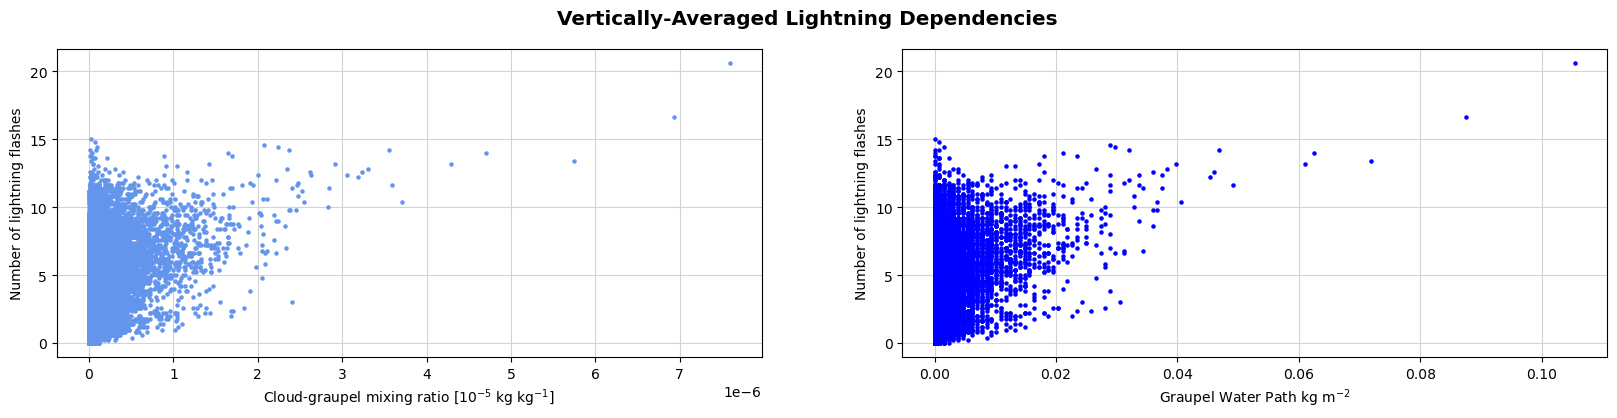

In [ ]:
## Graupel's effect on LFR (both cubes are essentially the same just one is dimensionless)

graupel_fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4))
graupel_fig.suptitle('Vertically-Averaged Lightning Dependencies', fontsize='x-large', weight='bold')

# ax1.scatter(t_i_w_p, l_f_r, s = 5, facecolor = 'cornflowerblue', zorder = 3)
# ax1.grid(True, color = 'lightgrey', zorder = 0)
# ax1.set_xlabel(r"Total ice water path [kg m$^{-2}$]")
# ax1.set_ylabel("Number of lightning flashes")
# ax1.set_title('Vertical Ice Extent')

# ax2.scatter(c_v_f_a, l_f_r, s = 5, facecolor = 'royalblue', zorder = 3)
# ax2.grid(True, color = 'lightgrey', zorder = 0)
# ax2.set_xlabel(r"Cloud volume fraction in atmosphere")
# ax2.set_ylabel("Number of lightning flashes")
# ax2.set_title('Cloud Volume Fraction')

ax1.scatter(g_m_r, l_f_r, s = 5, facecolor = 'cornflowerblue', zorder = 3)
ax1.grid(True, color = 'lightgrey', zorder = 0)
# ax1.set_xticks(
    # [2.5e-5, 5.0e-5, 7.5e-5, 1.0e-4, 1.25e-4, 1.5e-4], 
    # ['2.5', '5.0', '7.5', '10.0', '12.5', '15.0']
    # )
ax1.set_xlabel(r"Cloud-graupel mixing ratio [$10^{-5}$ kg kg$^{-1}$]")
ax1.set_ylabel("Number of lightning flashes")
# ax1.set_title('Cloud Ice Mixing Ratio')

ax2.scatter(g_w_p, l_f_r, s = 5, facecolor = 'blue', zorder = 3)
ax2.grid(True, color = 'lightgrey', zorder = 0)
ax2.set_xlabel(r"Graupel Water Path kg m$^{-2}$")
ax2.set_ylabel("Number of lightning flashes")
# ax2.set_title('Surface Temperature')



# LFR_dependencies.legend(
#     ncols=5,
#     loc='upper center',
#     bbox_to_anchor=(0.5, 0.93),
#     frameon=False
# )

# LFR_dependencies.subplots_adjust(top=0.8)


graupel_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/graupel_fig.png',
    bbox_inches="tight",
    pad_inches=0
)


In [ ]:
## Loading total ice water path data for other surface pressures

point_25_TIWP = total_ice_water_path(point_25)
point_5_TIWP = total_ice_water_path(point_5)
one_TIWP = total_ice_water_path(one)
two_TIWP = total_ice_water_path(two)

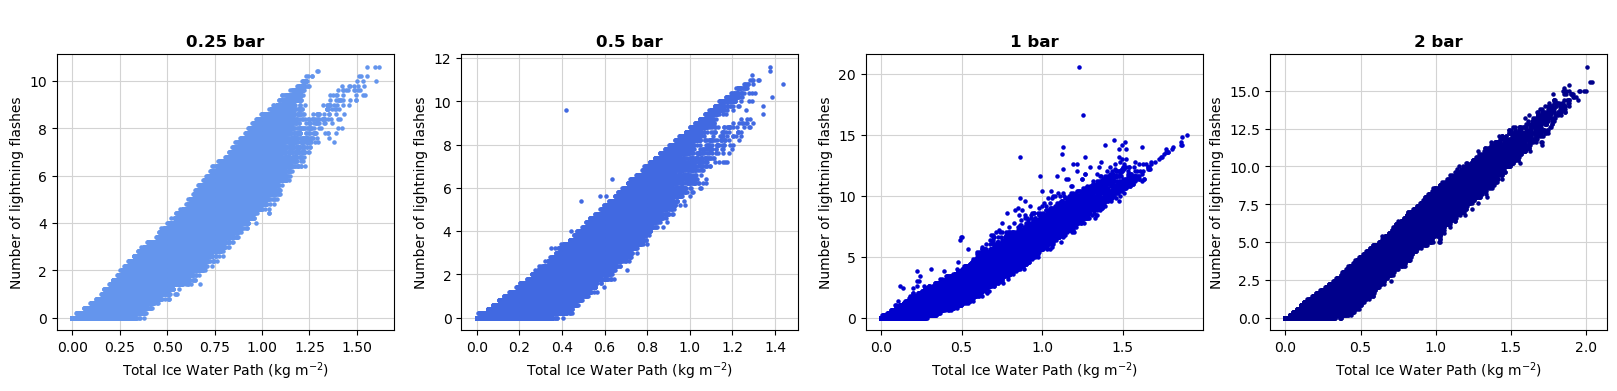

In [ ]:
## Plotting the LFR-TIWP cases for the four surface pressures

LFR_TIWP_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
LFR_TIWP_fig.suptitle('', fontsize='x-large', weight='bold')

ax1.scatter(point_25_TIWP, point_25_full_LFRdata, s = 5, facecolor = 'cornflowerblue', zorder = 3)
ax1.grid(True, color = 'lightgrey', zorder = 0)
ax1.set_xlabel(r"Total Ice Water Path (kg m$^{-2}$)")
ax1.set_ylabel("Number of lightning flashes")
ax1.set_title('0.25 bar', weight='bold')

ax2.scatter(point_5_TIWP, point_5_full_LFRdata, s = 5, facecolor = 'royalblue', zorder = 3)
ax2.grid(True, color = 'lightgrey', zorder = 0)
ax2.set_xlabel(r"Total Ice Water Path (kg m$^{-2}$)")
ax2.set_ylabel("Number of lightning flashes")
ax2.set_title('0.5 bar', weight='bold')

ax3.scatter(one_TIWP, one_full_LFRdata, s = 5, facecolor = 'mediumblue', zorder = 3)
ax3.grid(True, color = 'lightgrey', zorder = 0)
ax3.set_xlabel(r"Total Ice Water Path (kg m$^{-2}$)")
ax3.set_ylabel("Number of lightning flashes")
ax3.set_title('1 bar', weight='bold')

ax4.scatter(two_TIWP, two_full_LFRdata, s = 5, facecolor = 'darkblue', zorder = 3)
ax4.grid(True, color = 'lightgrey', zorder = 0)
ax4.set_xlabel(r"Total Ice Water Path (kg m$^{-2}$)")
ax4.set_ylabel("Number of lightning flashes")
ax4.set_title('2 bar', weight='bold')


LFR_TIWP_fig.legend(
    ncols=5,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    frameon=False
)

LFR_TIWP_fig.subplots_adjust(top=0.8)


LFR_TIWP_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/TIWP_LFR.png',
    bbox_inches="tight",
    pad_inches=0
)


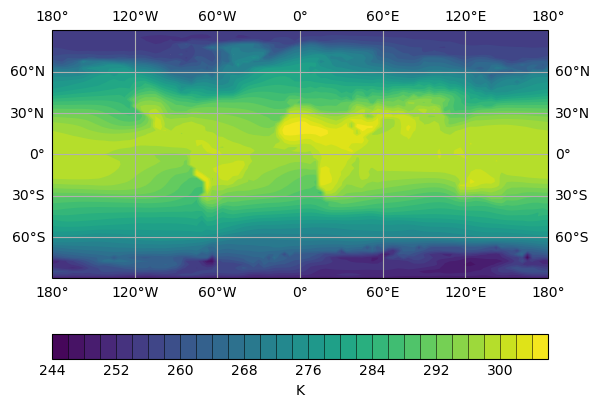

In [ ]:
# Plotting a filled contour plot for mean Earth air temperature
earthtemp = iris.sample_data_path("air_temp.pp")
earth_temperature_cube = iris.load_cube(earthtemp)
qplt.contourf(earth_temperature_cube, 35)
plt.gca().gridlines(draw_labels=True)
plt.title('')
plt.savefig('/data/cluster4/jj22956/lightning_figures/temp_maps/earth_air_temp_filled_contours.pdf')
plt.show()

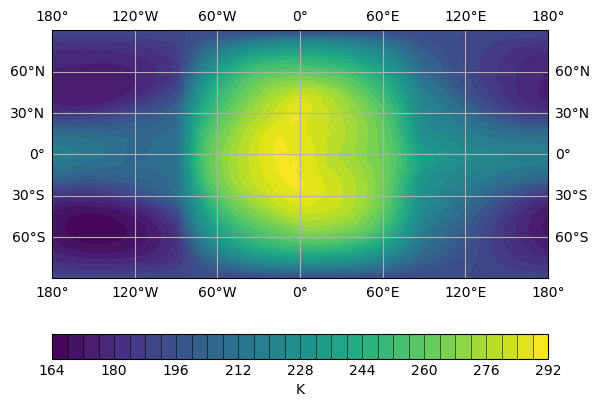

In [ ]:
# Plotting a filled contour plot for TRAPPIST-1e surface temperature
trappist1e_temperature_cube = one.extract_cube('m01s00i024')
qplt.contourf(trappist1e_temperature_cube, 35)
plt.savefig('/data/cluster4/jj22956/lightning_figures/temp_maps/trappist1e_air_temp_filled_contours.pdf')
plt.gca().gridlines(draw_labels=True)
plt.title('')
plt.show()